### Define how many signal and background particles there should be

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

In [2]:
n_signal = 10000
n_background = 1000000

## Create data - simple model

In [3]:
np.random.seed(42)

# Signal candidates
pt_sig = np.random.normal(loc=4.0, scale=1.0, size=n_signal)
decay_length_sig = np.random.normal(loc=0.12, scale=0.03, size=n_signal)
cos_pa_sig = np.random.normal(loc=0.995, scale=0.003, size=n_signal)
dca_sig = np.random.normal(loc=0.02, scale=0.01, size=n_signal)
pid_sig = np.random.normal(loc=0.85, scale=0.08, size=n_signal)

# Background candidates
pt_bkg = np.random.normal(loc=2.5, scale=1.2, size=n_background)
decay_length_bkg = np.random.normal(loc=0.04, scale=0.03, size=n_background)
cos_pa_bkg = np.random.normal(loc=0.93, scale=0.03, size=n_background)
dca_bkg = np.random.normal(loc=0.08, scale=0.03, size=n_background)
pid_bkg = np.random.normal(loc=0.45, scale=0.15, size=n_background)


X_sig = np.column_stack([pt_sig, decay_length_sig, cos_pa_sig, dca_sig, pid_sig])
X_bkg = np.column_stack([pt_bkg, decay_length_bkg, cos_pa_bkg, dca_bkg, pid_bkg])

y_sig = np.ones(n_signal)
y_bkg = np.zeros(n_background)

X = np.vstack([X_sig, X_bkg])
y = np.concatenate([y_sig, y_bkg])

feature_names = ["pt", "decay_length", "cos_pointing_angle", "dca_daughters", "pid_score"]


X[:, 0] = np.clip(X[:, 0], 0, None)   # pt >= 0
X[:, 1] = np.clip(X[:, 1], 0, None)   # decay length >= 0
X[:, 2] = np.clip(X[:, 2], -1, 1)     # cos(theta) in [-1, 1]
X[:, 3] = np.clip(X[:, 3], 0, None)   # dca >= 0
X[:, 4] = np.clip(X[:, 4], 0, 1)      # pid score in [0, 1]

# --- constants ---
m_Lc = 2.286  # GeV
sigma = 0.01  # resolution

# --- create mass ---
mass = np.zeros(len(y))

# signal (y == 1) → Gaussian peak
mass[y == 1] = np.random.normal(m_Lc, sigma, size=(y == 1).sum())

# background (y == 0) → flat in ±5σ
mass[y == 0] = np.random.uniform(
    m_Lc - 5*sigma,
    m_Lc + 5*sigma,
    size=(y == 0).sum()
)


print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("First 5 candidates:\n", X[:5])
print("First 5 labels:", y[:5])

Shape of X: (1010000, 5)
Shape of y: (1010000,)
First 5 candidates:
 [[4.49671415e+00 9.96451581e-02 9.96044859e-01 1.94280324e-04
  8.12251396e-01]
 [3.86173570e+00 1.10835016e-01 9.95849971e-01 9.45014353e-03
  9.31016198e-01]
 [4.64768854e+00 1.02078568e-01 9.92190440e-01 1.41297159e-02
  8.34145052e-01]
 [5.52302986e+00 1.23312541e-01 9.96738753e-01 2.14966891e-02
  8.57245541e-01]
 [3.76584663e+00 1.55915356e-01 9.90529752e-01 3.02416233e-02
  9.07391249e-01]]
First 5 labels: [1. 1. 1. 1. 1.]


# Plotting the variables distribution (normalised)
density = normalised to the number of enteries for each histogram (True/False)

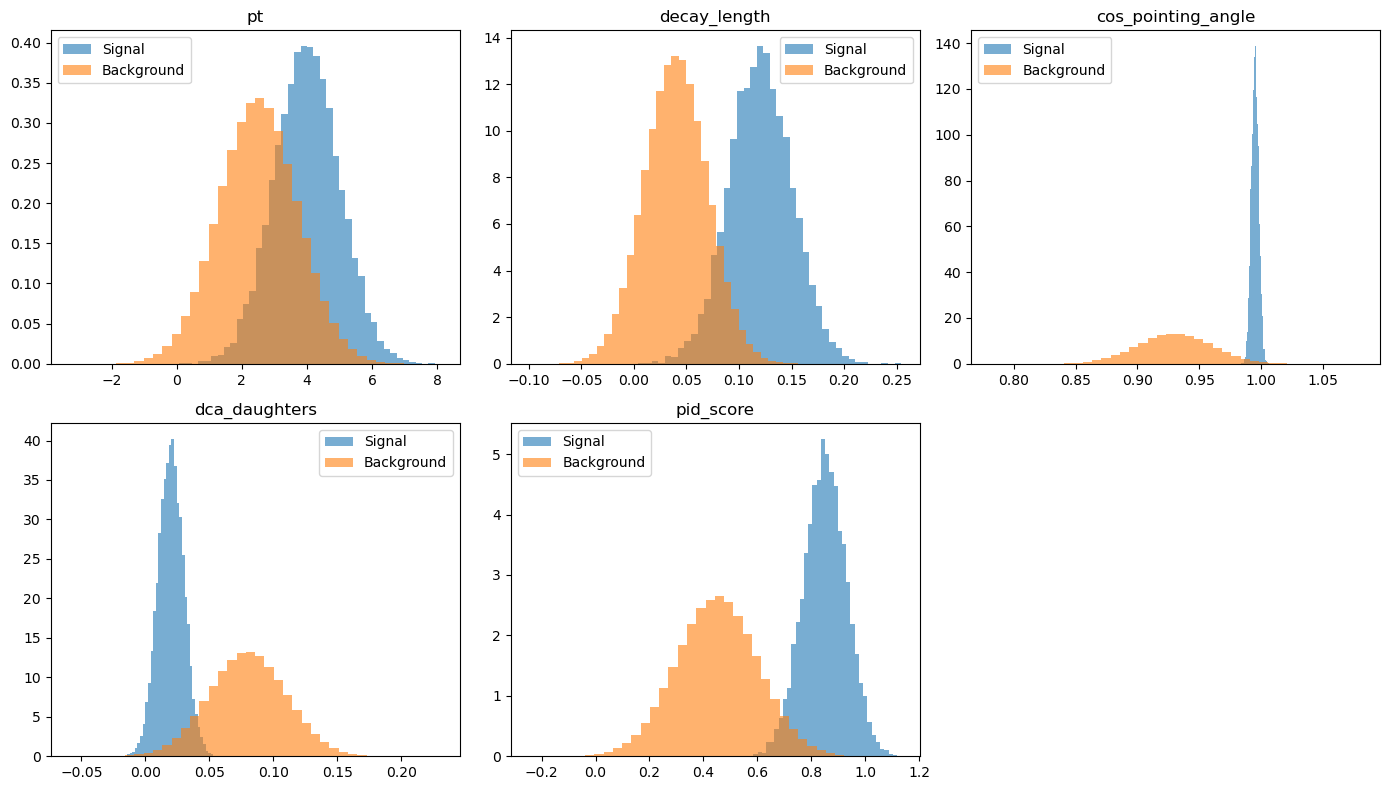

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, name in enumerate(feature_names):
    axes[i].hist(X_sig[:, i], bins=40, alpha=0.6, label="Signal", density=True)
    axes[i].hist(X_bkg[:, i], bins=40, alpha=0.6, label="Background", density=True)
    axes[i].set_title(name)
    axes[i].legend()

axes[5].axis("off")
plt.tight_layout()
plt.show()

# Split randomly data into training and testing dataset
X = array of features for each candidte

y = array of labels for sig and bkg (1 and 0 resp.)

test_size = [0,1] how much of the dataset will be used for testing, and the rest will be used for training

random_state = seet to make spliting reproducable

stratify = define class, which should be represented uniformly

In [16]:
## TODO

my_test_size = 0.2   # How much data should go to the test dataset (0-1)

X_train, X_test, y_train, y_test, mass_train, mass_test = train_test_split(
    X, y, mass,
    test_size=my_test_size,
    random_state=42,
    stratify=y
)

print("Training sample:", X_train.shape)
print("Testing sample:", X_test.shape)

Training sample: (808000, 5)
Testing sample: (202000, 5)


### Invariant mass distribtuion withou any cuts applied

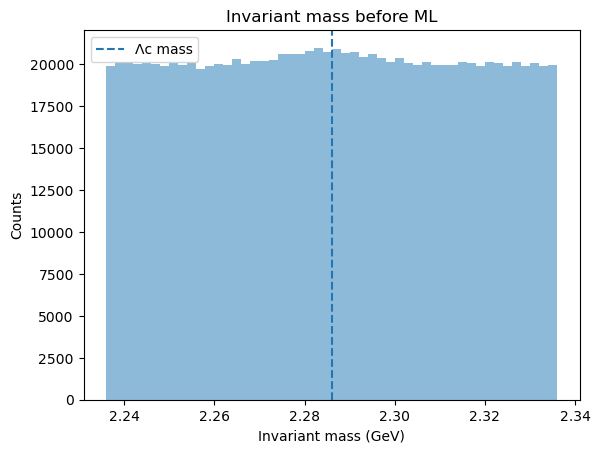

In [17]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(mass, bins=50, alpha=0.5)
plt.axvline(m_Lc, linestyle="--", label="Λc mass")
plt.xlabel("Invariant mass (GeV)")
plt.ylabel("Counts")
plt.legend()
plt.title("Invariant mass before ML")
plt.show()

# Define and train the model

n_estimators = number of trees (balance between better learning and overfilling)

max_depth = maximal depth of the tree (how many cuts there can be on each variable)

learning_rate = how buch does each tree contribute

subsample = how much data will each tree see (each tree sees random 80% of the original data)

colsample_bytree = how many variables does each tree see (each tree can thefore different use a bit variables)

eval_metric = which loss function it should use (log loss - high penalty for wrong prediction)

In [18]:
## TODO

my_n_estimators =  200   # how deep should the BDTs be? = number of trees
my_max_depth = 5        # how many branches there should be on each tree? = number of bins for the layer/variable
my_learning_rate = 0.1    # how does each tree contribute?  ... does not sum-up to 1.0 with number of trees

In [19]:
model = xgb.XGBClassifier(
    n_estimators=my_n_estimators,
    max_depth=my_max_depth,
    learning_rate=my_learning_rate,
    subsample=0.8,           # fraction of training data for each tree -> each tree has slightly different data
    colsample_bytree=0.8,    # fraction of layers/variables used 
    eval_metric="logloss",
    random_state=852
)

## !! THIS IS THE FINAL PRODUCT = TRAINED MODEL

In [20]:
model.fit(X_train, y_train)
print("Training finished.")

# ML scores = probability of being signal (class 1)
y_score_train = model.predict_proba(X_train)[:, 1]
y_score_test  = model.predict_proba(X_test)[:, 1]

Training finished.


# Run the trained model on the test data

y_pred = true labels of candidates (0/1)

y_prob = what it the probability, that they are a signal

In [21]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("First 10 predicted classes:", y_pred[93:96])
print("First 10 signal probabilities:", y_prob[93:96])

First 10 predicted classes: [0 0 0]
First 10 signal probabilities: [8.243311e-07 2.841902e-07 7.046570e-08]


# Efficiency plots and evaluation

### Accuracy and AUC (Area Under the Curve)

Accuracy = # of correct predictions / all candidates (Could be misleading)

AUC = how well the model separates signal from background (0.5 - random guess, 1.0 - perfect separation)

In [22]:
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy =", acc)
print("AUC =", auc)

Accuracy = 0.9999356435643565
AUC = 0.999999055


### ROC curve
#### Visual representation of the trade-offs between the true positive rate (TPR) and false positive rate (FPR) at various thresholds

tpr = TP/(TP+FN)

fpr = FP/(FP+TN)

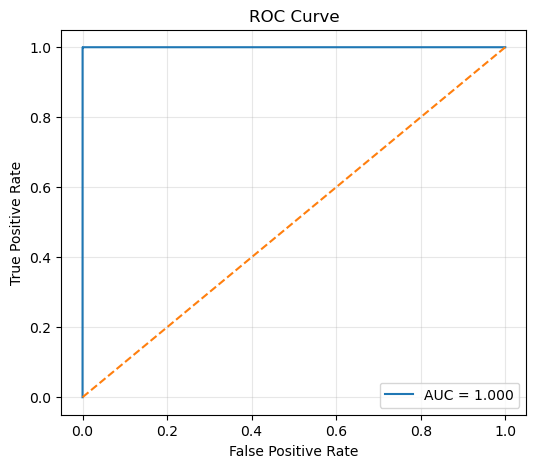

In [15]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Feature importance
Which variables were how much important during the model training

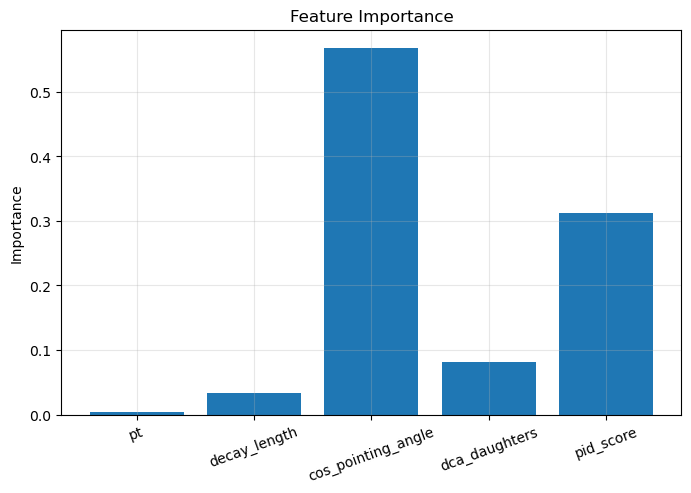

In [48]:
importances = model.feature_importances_

plt.figure(figsize=(8, 5))
plt.bar(feature_names, importances)
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.xticks(rotation=20)
plt.grid(alpha=0.3)
plt.show()

## Score distribution

How much likely are data to be signal or background [0, 1]

Distribution for both trained data and testing data.

If there is no distributional differnece between signal and bacground - model not trained enought

If trained signal close to 1 and testing signal uniform - overtained only on the data provided

If both signal systematicly data closer to 1 then background - well trained model

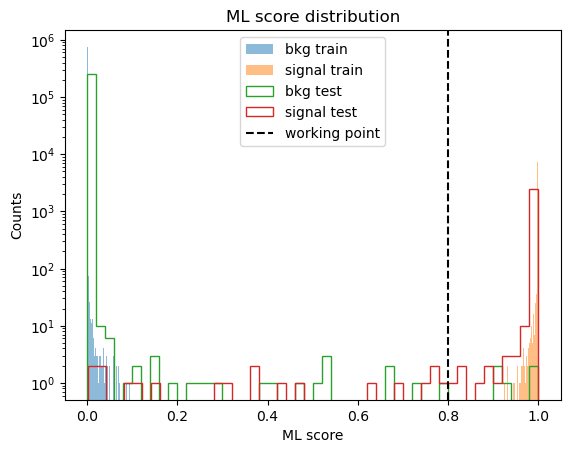

In [49]:
plt.figure()

plt.hist(y_score_train[y_train==0], bins=50, alpha=0.5, label="bkg train")
plt.hist(y_score_train[y_train==1], bins=50, alpha=0.5, label="signal train")

plt.hist(y_score_test[y_test==0], bins=50, histtype="step", label="bkg test")
plt.hist(y_score_test[y_test==1], bins=50, histtype="step", label="signal test")

plt.axvline(0.8, color="black", linestyle="--", label="working point")

plt.xlabel("ML score")
plt.ylabel("Counts")
plt.legend()
plt.title("ML score distribution")
plt.yscale("log")
plt.show()

In [39]:
cut = 0.8
selected = y_score_test > cut

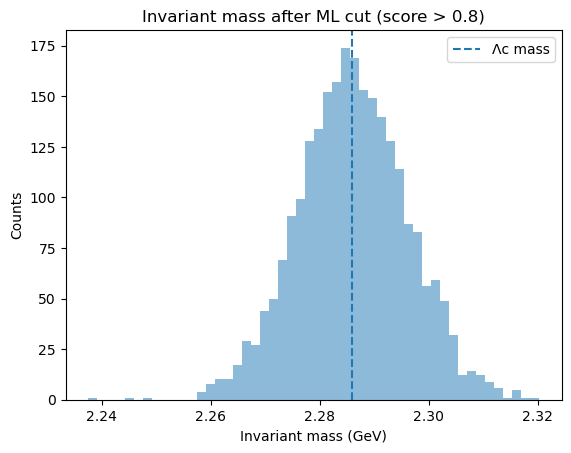

In [40]:
plt.figure()

plt.hist(mass_test[selected], bins=50, alpha=0.5)

plt.axvline(m_Lc, linestyle="--", label="Λc mass")

plt.xlabel("Invariant mass (GeV)")
plt.ylabel("Counts")
plt.legend()
plt.title("Invariant mass after ML cut (score > 0.8)")
plt.show()